In [1]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 93.1 MB/s eta 0:00:00:00:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=b17518acf3ec59e19bd504d6a291c274b5abf7c09a850fee0a6de5f13800602b
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [2]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
from PIL import Image
from collections import Counter
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import random
import numpy as np
import torch
import cv2
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [5]:
MAG = "200X"
DATA_ROOT = "/kaggle/input/breakhis/BreaKHis_v1//BreaKHis_v1/histology_slides/breast"

BATCH_SIZE = 32
NUM_EPOCHS = 100
LEARNING_RATE = 1e-4
PATIENCE = 25

CLASS_NAMES = [
    "adenosis",
    "fibroadenoma",
    "phyllodes_tumor",
    "tubular_adenoma",
    "ductal_carcinoma",
    "lobular_carcinoma",
    "mucinous_carcinoma",
    "papillary_carcinoma"
]

class_to_idx = {cls: i for i, cls in enumerate(CLASS_NAMES)}

In [6]:
def load_breakhis(mag="200X"):
    samples = []

    for root, _, files in os.walk(DATA_ROOT):
        if not root.endswith(mag):
            continue

        parts = root.split(os.sep)

        cls = None
        for c in CLASS_NAMES:
            if c in parts:
                cls = c
                break

        if cls is None:
            continue

        label = class_to_idx[cls]

        for f in files:
            if f.lower().endswith(".png"):
                samples.append((os.path.join(root, f), label))

    return samples

In [7]:
class BreakHisDataset(Dataset):

    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

        img_path, label = self.samples[idx]

        try:
            img = Image.open(img_path).convert("RGB")

            if self.transform:
                img = self.transform(img)

            return img, label

        except:
            return torch.zeros((3, 224, 224)), label

In [8]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((230, 230)),
    transforms.RandomRotation(1),
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])


In [9]:
full_samples = load_breakhis(MAG)

if not full_samples:
    raise ValueError("Không tìm thấy ảnh!")

print("Total samples:", len(full_samples))

Total samples: 2013


In [10]:
from sklearn.model_selection import train_test_split

train_samples, temp_samples = train_test_split(
    full_samples,
    test_size=0.2,
    stratify=[s[1] for s in full_samples],
    random_state=42
)

val_samples, test_samples = train_test_split(
    temp_samples,
    test_size=0.5,
    stratify=[s[1] for s in temp_samples],
    random_state=42
)

print("Train:", len(train_samples))
print("Val:", len(val_samples))
print("Test:", len(test_samples))

Train: 1610
Val: 201
Test: 202


In [11]:

train_targets = [s[1] for s in train_samples]
class_sample_count = Counter(train_targets)

weights = 1. / torch.tensor(
    [class_sample_count[i] for i in range(len(CLASS_NAMES))],
    dtype=torch.float
)

samples_weights = torch.tensor([weights[t] for t in train_targets])
sampler = WeightedRandomSampler(samples_weights, len(samples_weights))


In [12]:
train_ds = BreakHisDataset(train_samples, train_tf)
val_ds   = BreakHisDataset(val_samples, val_tf)
test_ds  = BreakHisDataset(test_samples, val_tf)  

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=sampler,   
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(   
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [13]:
def plot_distribution(counts, title):

    labels = CLASS_NAMES
    values = [counts[i] for i in range(len(labels))]

    plt.figure(figsize=(10,4))
    plt.bar(labels, values)
    plt.xticks(rotation=45, ha="right")
    plt.title(title)
    plt.show()


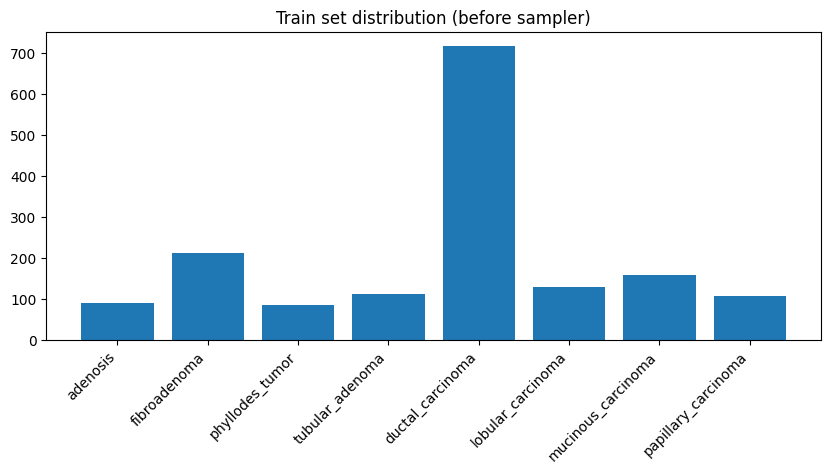

In [14]:
orig_counter = Counter(train_targets)
plot_distribution(orig_counter, "Train set distribution (before sampler)")

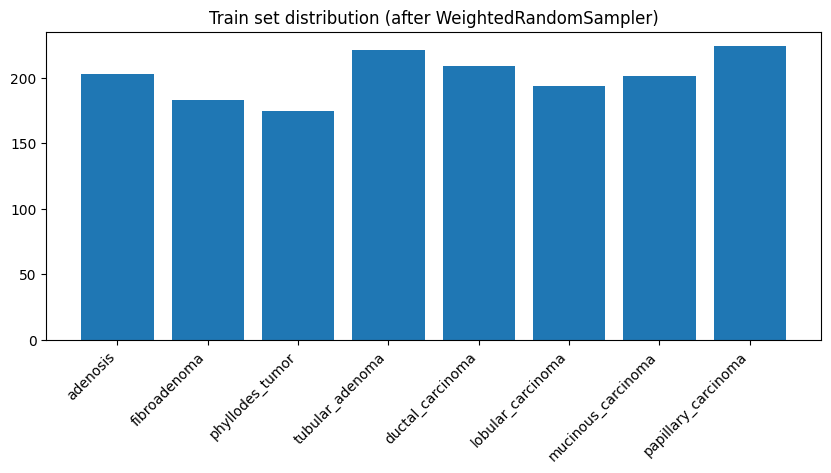

In [15]:
sampled_indices = list(iter(sampler))
sampled_labels = [train_targets[i] for i in sampled_indices]
sampled_counter = Counter(sampled_labels)

plot_distribution(sampled_counter, "Train set distribution (after WeightedRandomSampler)")


In [16]:
import torch
import torch.nn as nn
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights


class SEBlock(nn.Module):
    def __init__(self, channels, r=16):
        super().__init__()

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.fc = nn.Sequential(
            nn.Linear(channels, channels // r),
            nn.ReLU(),  
            nn.Linear(channels // r, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()

        y = self.pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)

        return x * y


class ConvNeXtSE(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()

        backbone = convnext_tiny(
            weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1
        )

        # feature extractor
        self.features = backbone.features

        self.se = SEBlock(768, r=16)

        # classifier head 
        self.pool = nn.AdaptiveAvgPool2d(1)

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.LayerNorm(768),
            nn.Dropout(0.5),
            nn.Linear(768, num_classes)
        )

    def forward(self, x):
        x = self.features(x)   # (B, 768, H, W)
        x = self.se(x)         # SE attention
        x = self.pool(x)       # (B, 768, 1, 1)
        x = self.head(x)       # classifier
        return x

In [17]:
model = ConvNeXtSE().to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.15)

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-2
)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LEARNING_RATE,
    steps_per_epoch=len(train_loader),
    epochs=NUM_EPOCHS,
    pct_start=0.3
)


Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 182MB/s] 


In [18]:
def calculate_metrics(y_true, y_pred):

    acc = accuracy_score(y_true, y_pred)

    p, r, f, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average='macro',
        zero_division=0
    )

    return acc, p, r, f

In [19]:
seed=42
set_seed(seed)

train_losses = []
val_losses   = []
train_accs   = []
val_accs     = []

best_f1 = 0.0
best_epoch = 0
best_state = None
best_metrics = None
best_pred = None  
patience_counter = 0

import copy  

print(f"{'Epoch':^6} | {'Train Loss':^10} | {'Val Loss':^9} | {'Val Acc':^9} | {'Val Prec':^9} | {'Val Rec':^9} | {'Val F1':^9} | Status")
print("-" * 110)

for epoch in range(1, NUM_EPOCHS + 1):

    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch}", leave=False):

        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(imgs)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        scheduler.step()

        train_loss += loss.item()

        preds = outputs.argmax(1)

        train_correct += (preds == labels).sum().item()

        train_total += labels.size(0)

    avg_train_loss = train_loss / len(train_loader)

    train_acc = train_correct / train_total

    model.eval()

    y_true, y_pred = [], []

    val_loss = 0.0

    with torch.no_grad():

        for imgs, labels in val_loader:

            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    val_loss /= len(val_loader)

    val_acc, val_prec, val_rec, val_f1 = calculate_metrics(y_true, y_pred)

    train_losses.append(avg_train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    status = ""

    if val_f1 > best_f1:

        best_f1 = val_f1
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())
        best_metrics = (val_acc, val_prec, val_rec, val_f1)
        best_pred = (y_true.copy(), y_pred.copy())

        patience_counter = 0
        status = "BEST"

    else:

        patience_counter += 1

    print(f"{epoch:^6} | {avg_train_loss:^10.4f} | {val_loss:^9.4f} | "
          f"{val_acc*100:^8.2f}% | {val_prec*100:^8.2f}% | "
          f"{val_rec*100:^8.2f}% | {val_f1*100:^8.2f}% | {status}")

    if patience_counter >= PATIENCE:

        print(f"\nEarly stopping at epoch {epoch}")
        break

Epoch  | Train Loss | Val Loss  |  Val Acc  | Val Prec  |  Val Rec  |  Val F1   | Status
--------------------------------------------------------------------------------------------------------------


  1    |   2.2843   |  2.0871   |  12.44  % |  13.12  % |  17.42  % |  11.68  % | BEST


  2    |   2.1025   |  1.9875   |  25.87  % |  26.40  % |  35.76  % |  25.73  % | BEST


  3    |   1.9847   |  1.8829   |  35.82  % |  38.23  % |  48.78  % |  35.82  % | BEST


  4    |   1.8093   |  1.6720   |  45.77  % |  45.31  % |  53.86  % |  44.08  % | BEST


...

  57   |   0.6784   |  0.7835   |  92.54  % |  93.31  % |  89.03  % |  90.15  % | 


  58   |   0.6698   |  0.7720   |  92.54  % |  92.51  % |  89.54  % |  89.74  % | 


  59   |   0.6656   |  0.7747   |  93.03  % |  93.19  % |  90.48  % |  91.22  % | 


  60   |   0.6948   |  0.7653   |  94.03  % |  92.20  % |  92.55  % |  92.05  % | 


  61   |   0.6669   |  0.7775   |  92.04  % |  91.67  % |  90.47  % |  90.07  % | 

Early stopping at epoch 61


In [20]:
model.load_state_dict(best_state)
model.eval()

y_true_test, y_pred_test = [], []

with torch.no_grad():
    for imgs, labels in test_loader:

        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1)

        y_true_test.extend(labels.cpu().numpy())
        y_pred_test.extend(preds.cpu().numpy())

In [21]:
test_acc, test_prec, test_rec, test_f1 = calculate_metrics(
    y_true_test, y_pred_test
)


In [22]:
print("\nFINAL TEST RESULT")
print(f" Accuracy  : {test_acc*100:.2f}%")
print(f" Precision : {test_prec*100:.2f}%")
print(f" Recall    : {test_rec*100:.2f}%")
print(f" F1-score  : {test_f1*100:.2f}%")


FINAL TEST RESULT
 Accuracy  : 95.05%
 Precision : 94.37%
 Recall    : 96.04%
 F1-score  : 95.17%


In [23]:
y_true, y_pred = best_pred
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


Classification Report:
                     precision    recall  f1-score   support

           adenosis       0.92      1.00      0.96        11
       fibroadenoma       0.96      1.00      0.98        26
    phyllodes_tumor       1.00      0.73      0.84        11
    tubular_adenoma       1.00      1.00      1.00        14
   ductal_carcinoma       0.98      0.96      0.97        89
  lobular_carcinoma       0.77      1.00      0.87        17
 mucinous_carcinoma       1.00      0.89      0.94        19
papillary_carcinoma       1.00      1.00      1.00        14

           accuracy                           0.96       201
          macro avg       0.95      0.95      0.95       201
       weighted avg       0.96      0.96      0.96       201



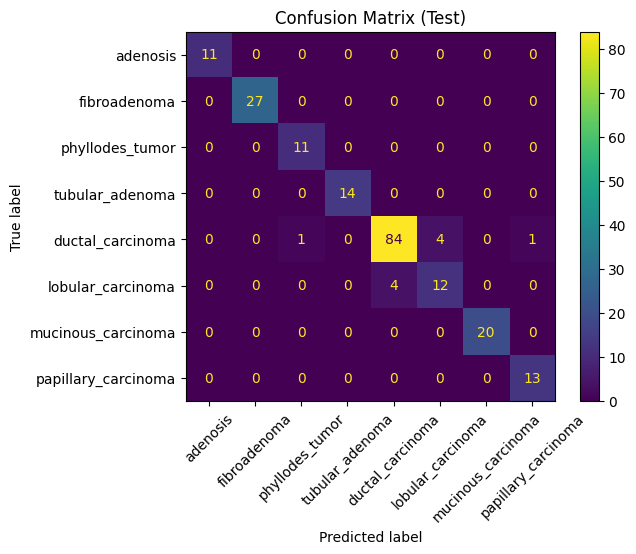

In [24]:
cm = confusion_matrix(y_true_test, y_pred_test)
disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix (Test)")
plt.show()

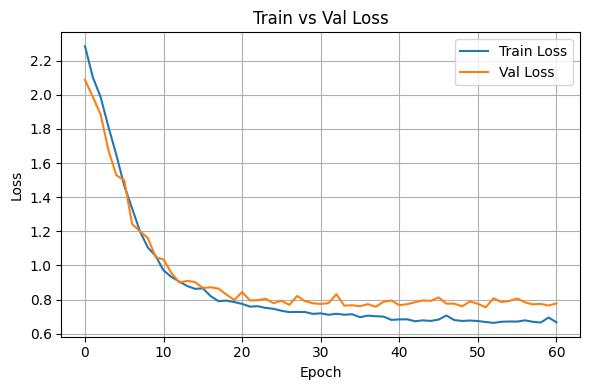

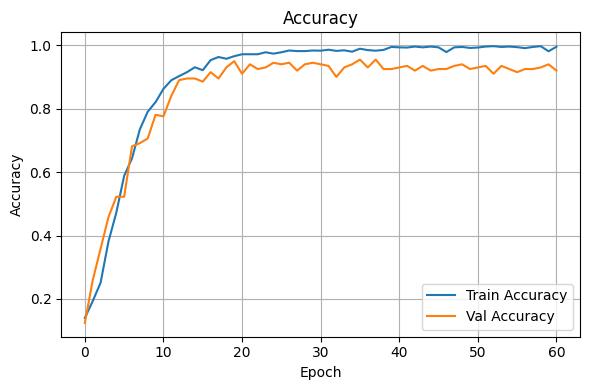

In [25]:
plt.figure(figsize=(6,4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.title("Train vs Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Val Accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [26]:
features, gradients = [], []

def forward_hook(module, input, output):
    features.clear()
    features.append(output)

def backward_hook(module, grad_input, grad_output):
    gradients.clear()
    gradients.append(grad_output[0])

target_layer = model.features[-1]
target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)

def grad_cam_single(img, class_idx):
    model.eval()
    img = img.unsqueeze(0).to(device)

    features.clear()
    gradients.clear()

    out = model(img)
    model.zero_grad()

    out[0, class_idx].backward()

    fmap = features[0]
    grad = gradients[0]

    weights = grad.mean(dim=(2,3), keepdim=True)
    cam = (weights * fmap).sum(dim=1).squeeze()

    cam = cam.detach().cpu().numpy()
    cam = np.maximum(cam, 0)

    if cam.max() != 0:
        cam = cam / cam.max()

    return cam

def grad_cam_all_classes(img):
    cams = []
    for class_idx in range(len(CLASS_NAMES)):
        cam = grad_cam_single(img, class_idx)
        cam = cv2.resize(cam, (224,224))
        cams.append(cam)
    return cams

In [27]:
from sklearn.metrics import f1_score

# lấy kết quả tốt nhất từ training
y_true, y_pred = best_pred

# tính F1 từng class
f1_per_class = f1_score(y_true, y_pred, average=None)

# chọn class tốt nhất
best_class_idx = np.argmax(f1_per_class)

print("Best class:", CLASS_NAMES[best_class_idx])

Best class: tubular_adenoma


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


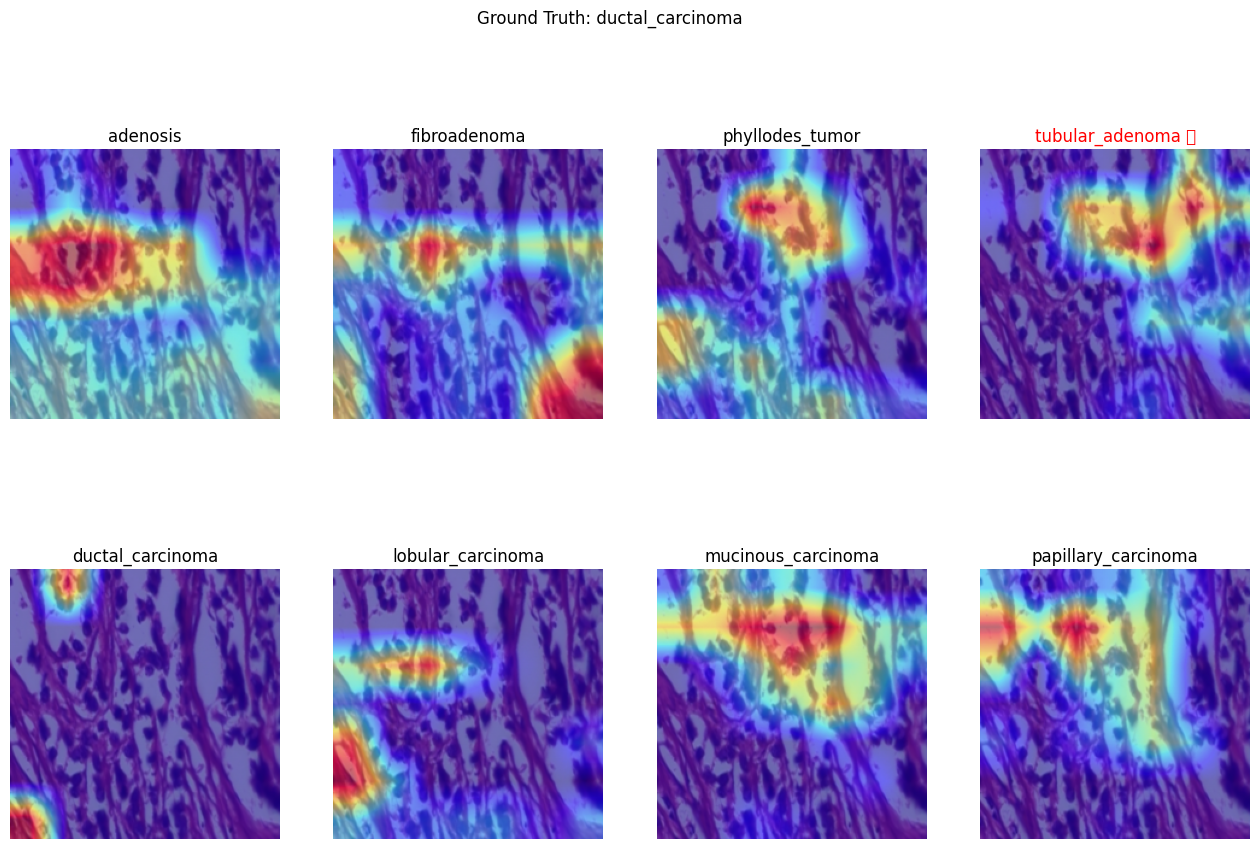

In [28]:
img, label = test_ds[0]
cams = grad_cam_all_classes(img)

img_np = img.permute(1,2,0).numpy()
img_np = (img_np - img_np.min())/(img_np.max()-img_np.min())

plt.figure(figsize=(16,10))
for i, cam in enumerate(cams):
    plt.subplot(2,4,i+1)
    plt.imshow(img_np)
    plt.imshow(cam, cmap='jet', alpha=0.5)

    if i == best_class_idx:
        plt.title(f"{CLASS_NAMES[i]} ⭐", color='red')
    else:
        plt.title(CLASS_NAMES[i])

    plt.axis('off')

plt.suptitle(f"Ground Truth: {CLASS_NAMES[label]}")
plt.show()